# Maintenance Pipeline Explorer

Walk through every stage of `compute_maintenance` on synthetic scenarios.
Each scenario produces a 6-panel figure showing:

1. **Weight + Slope** — raw measurements, WLS raw & blended slope
2. **Calories + EWMA** — raw bars, EWMA smoothed, blended with fallback
3. **Confidence** — weight & calorie confidence ramps over time
4. **Blending** — how fallback fraction fades as data accumulates
5. **Maintenance** — estimated vs true TDEE vs fallback
6. **Validity & Flags** — is_valid, is_suspect, slope_clamped, data point counts

Edit `SCENARIOS` in `sim.py` or define custom ones inline below.

In [10]:
from datetime import date

import matplotlib.pyplot as plt

from sim import *

REF = date(2026, 2, 21)

# List the built-in scenarios
for key, sc in SCENARIOS.items():
    print(f"  {key:15s} — {sc.name}")

  steady          — Steady State
  deficit         — 500 kcal Deficit
  surplus         — 300 kcal Surplus
  new_user        — New User (data ramp-up)
  gap             — Week-long gap mid-window
  regime_shift    — Diet break → resume
  sparse          — Sparse weigher (weekly)
  noisy           — Very noisy data


## Run all built-in scenarios

Pick which ones to show, or run them all.

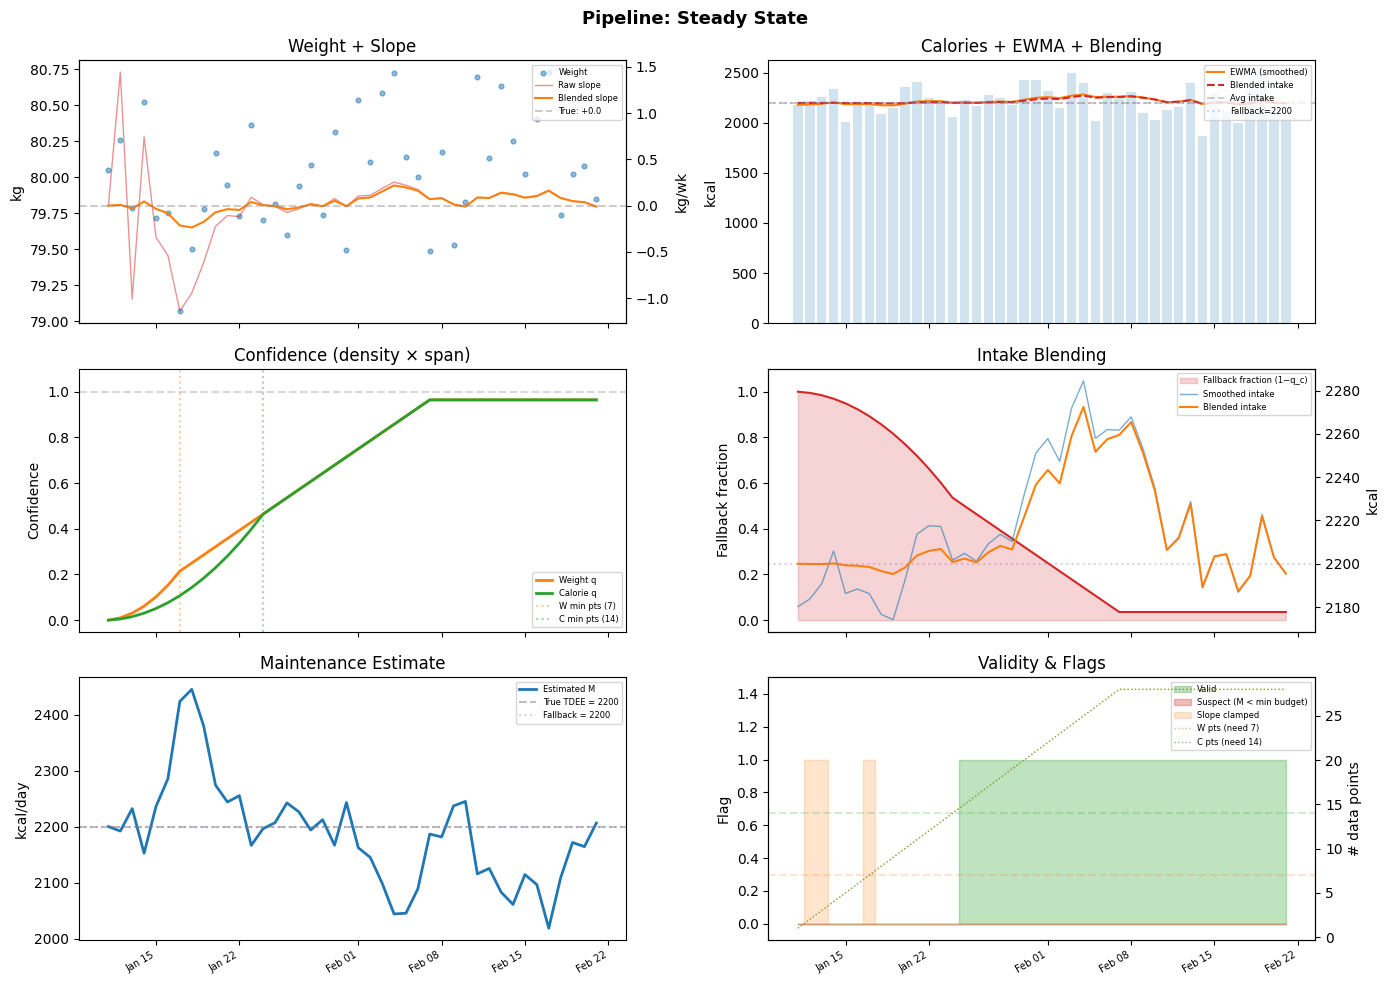

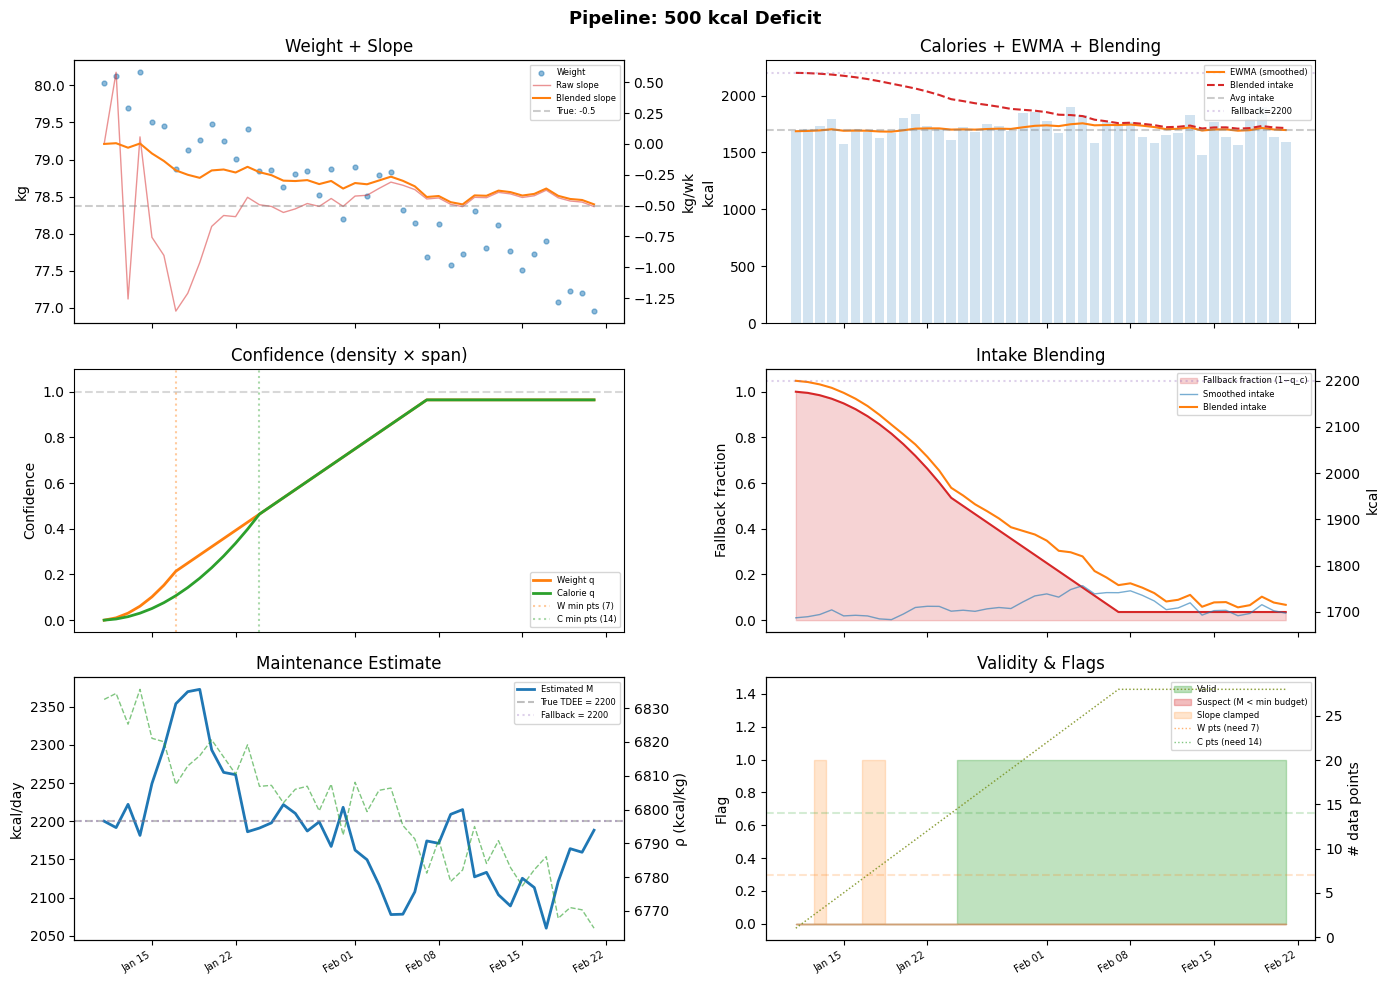

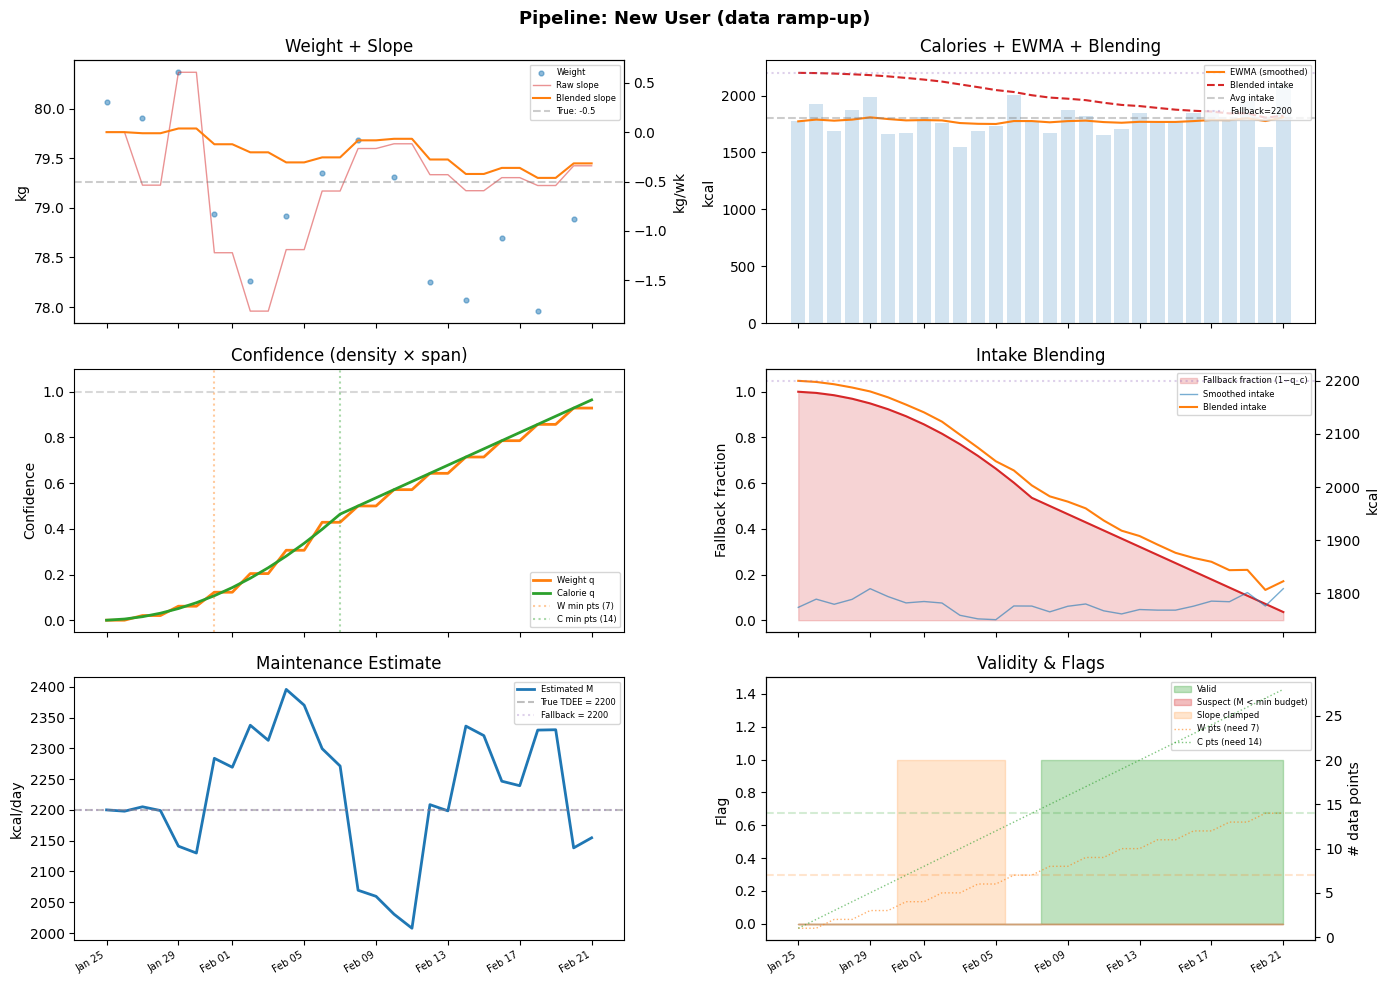

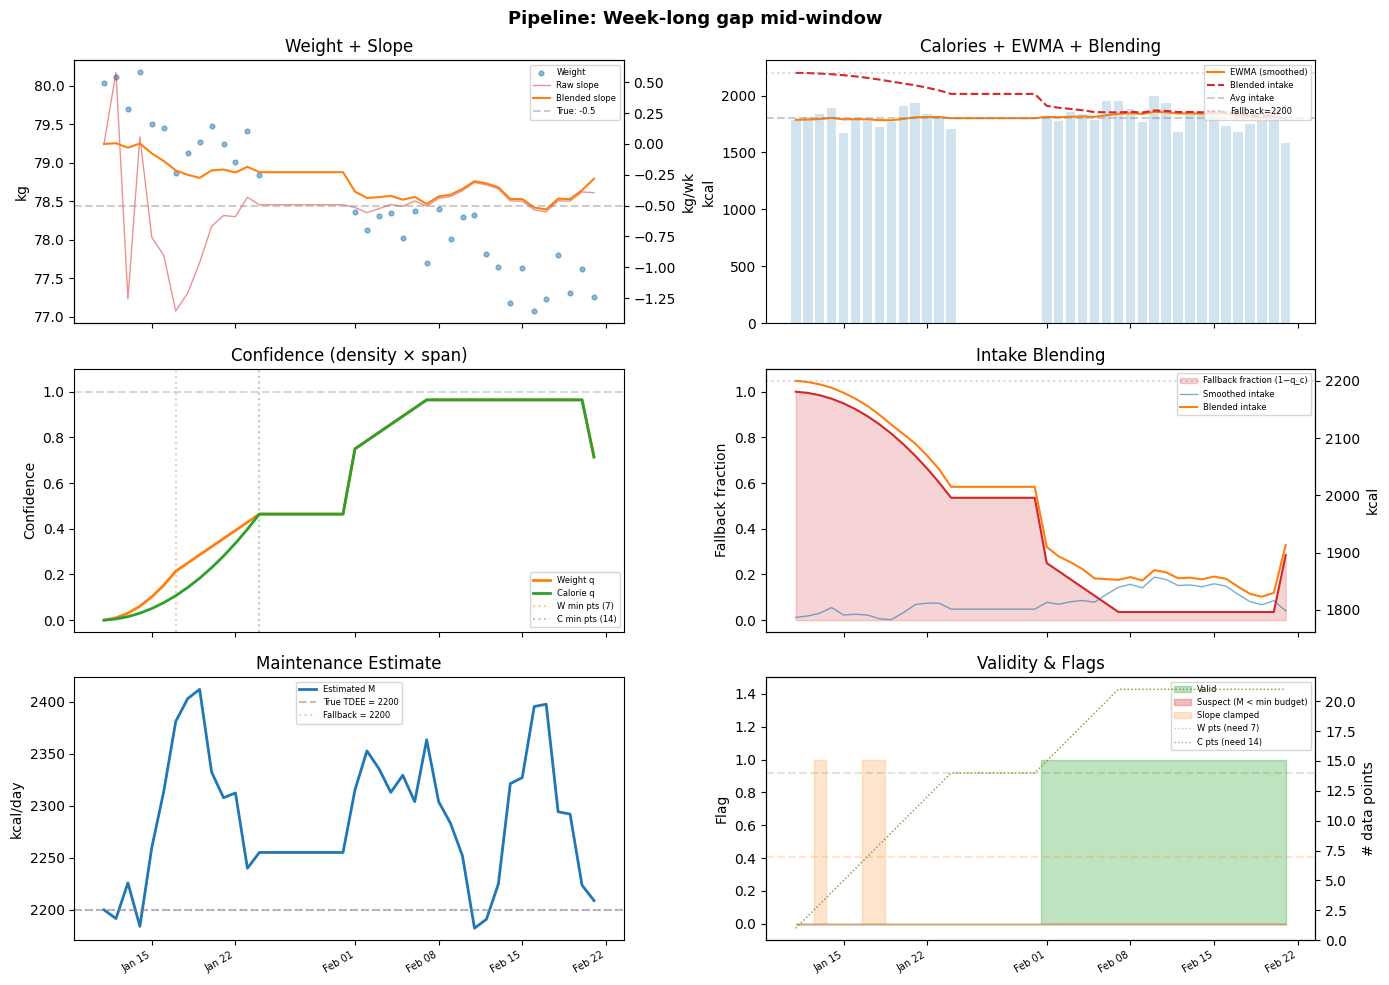

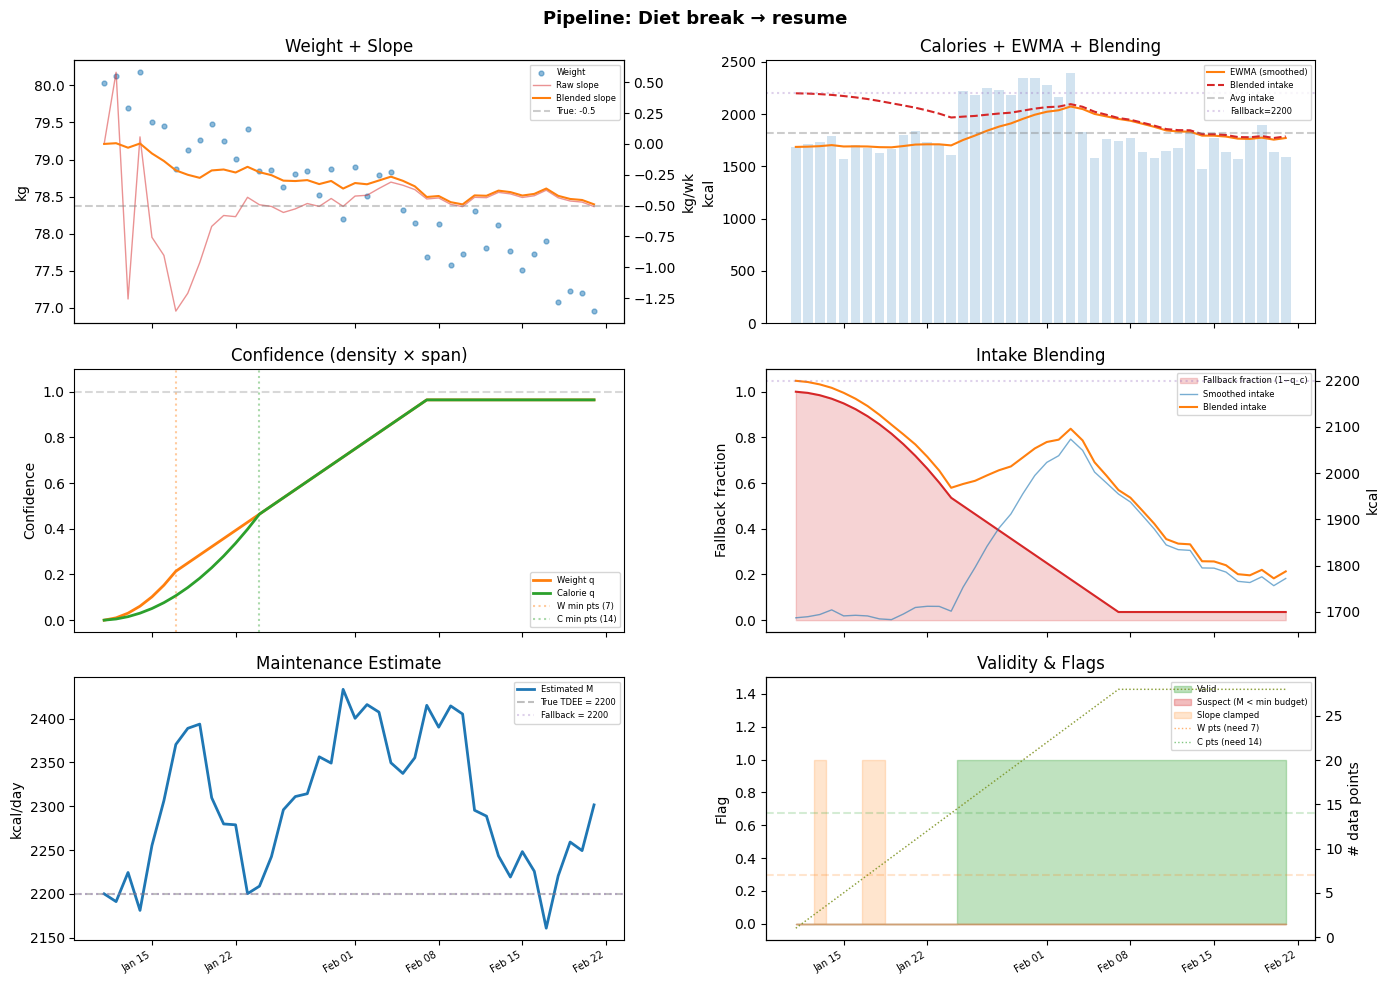

In [11]:
# Choose scenarios to plot (comment/uncomment as needed)
selected = [
    "steady",
    "deficit",
    "new_user",
    "gap",
    "regime_shift",
    # "surplus",
    # "sparse",
    # "noisy",
]

for key in selected:
    plot_pipeline(SCENARIOS[key], REF)
    plt.show()

## Custom scenario: Comeback after year-long break

2 months of proper deficit tracking (losing ~0.5 kg/wk at 1700 kcal), then **1 year of silence**,
then new data starts arriving from a higher weight going in the opposite direction (gaining on a bulk at 2800 kcal).

This stress-tests: confidence decay during the gap, stale slope/EWMA carrying over,
and whether the pipeline recovers once new data accumulates.

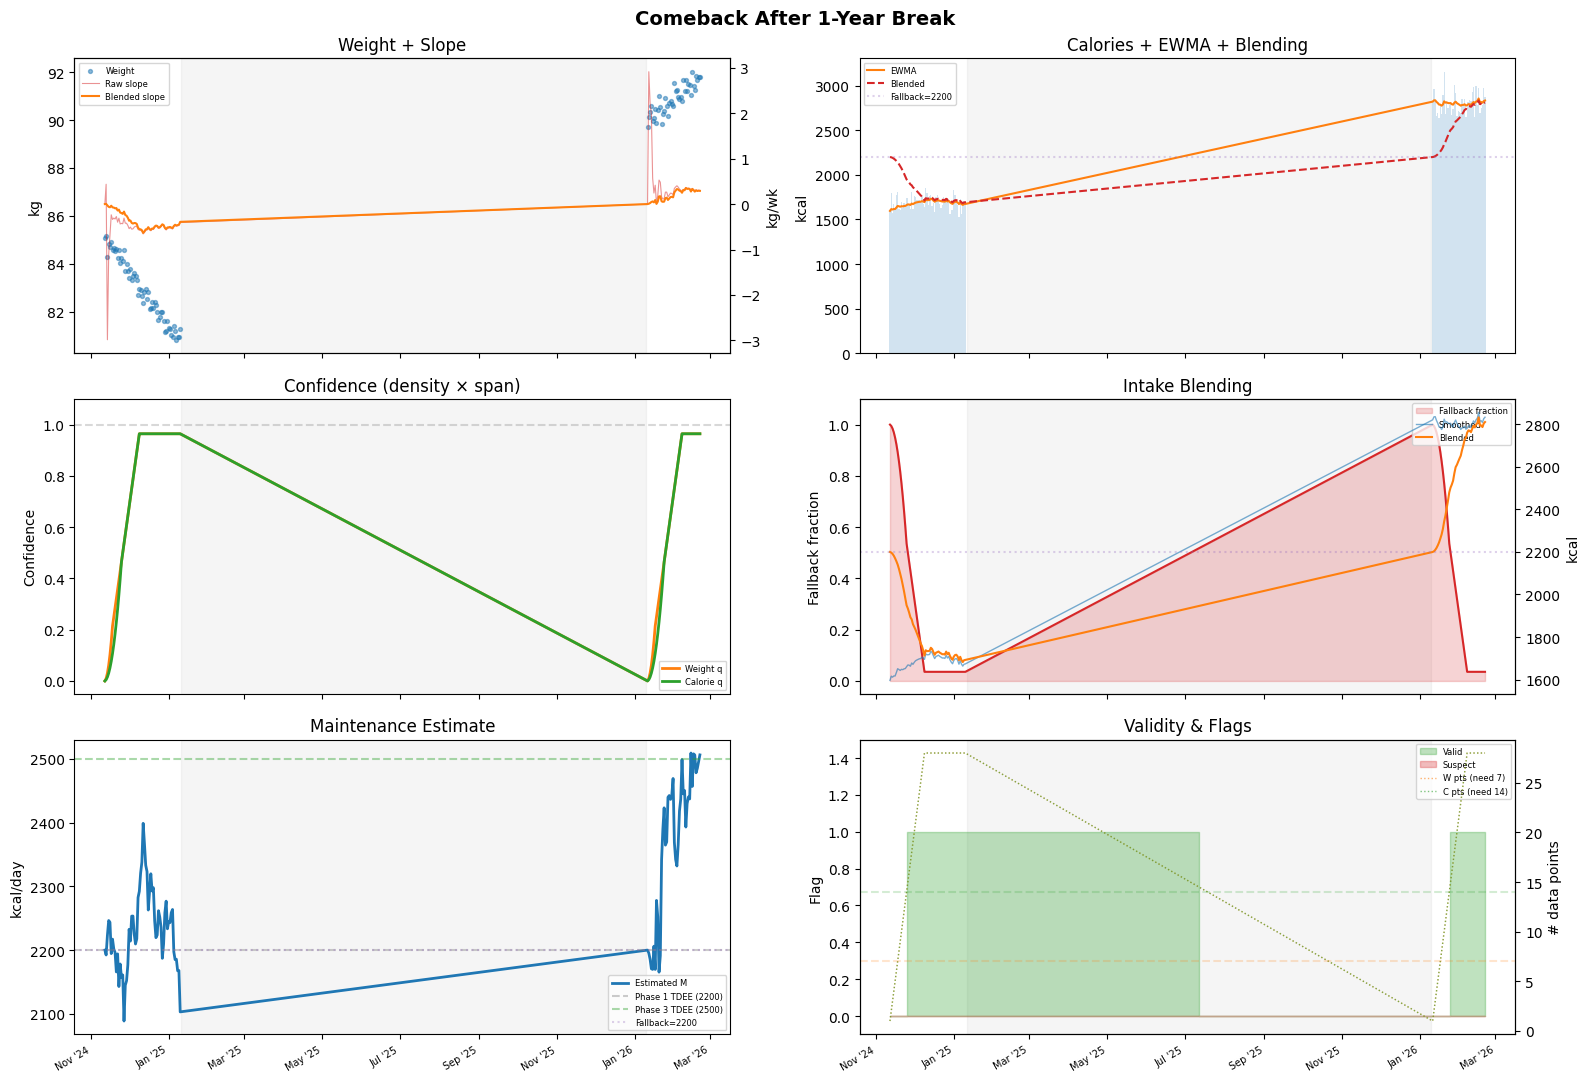


        Date    Phase   W_q   C_q   Maint   Slope  Valid
------------------------------------------------------------
  2024-11-12      Cut  0.00  0.00    2200   +0.00      ✗
  2024-11-26      Cut  0.50  0.50    2161   -0.22      ✓
  2024-12-11      Cut  0.96  0.96    2338   -0.58      ✓
  2025-01-10      Cut  0.96  0.96    2103   -0.39      ✓
  2026-01-11     Bulk  0.00  0.00    2200   +0.00      ✗
  2026-01-18     Bulk  0.25  0.14    2278   +0.00      ✗
  2026-01-25     Bulk  0.50  0.50    2365   +0.13      ✓
  2026-02-07     Bulk  0.96  0.96    2499   +0.25      ✓
  2026-02-21     Bulk  0.96  0.96    2506   +0.29      ✓


In [12]:
import numpy as np
import matplotlib.dates as mdates
from model import ewma, wls_slope, forbes_rho, compute_maintenance, data_stats
from sim import rolling_pipeline, plot_pipeline

# ── Build the dataset manually ──
rng = np.random.default_rng(42)

# Phase 1: 60 days of cutting (losing ~0.5 kg/wk, eating 1700, true TDEE ~2200)
phase1_days = 60
# Phase 2: 365 days of nothing
gap_days = 365
# Phase 3: 42 days of bulking (gaining ~0.3 kg/wk, eating 2800, true TDEE ~2500 — higher from gained muscle)
phase3_days = 42

total_days = phase1_days + gap_days + phase3_days
comeback_ref = REF  # everything ends at REF

weights = {}
calories = {}

for d in range(total_days):
    dt = comeback_ref - timedelta(days=total_days - 1 - d)

    if d < phase1_days:
        # Phase 1: cutting
        true_w = 85.0 + (-0.5 / 7) * d
        weights[dt] = true_w + rng.normal(0, 0.3)
        calories[dt] = 1700 + rng.normal(0, 100)

    elif d < phase1_days + gap_days:
        # Phase 2: gap — no data at all
        pass

    else:
        # Phase 3: bulking from new starting point
        d3 = d - (phase1_days + gap_days)
        true_w = 90.0 + (0.3 / 7) * d3  # gained weight during the year off
        weights[dt] = true_w + rng.normal(0, 0.3)
        calories[dt] = 2800 + rng.normal(0, 120)

body_fat = {}  # no BF data

# ── Run pipeline day-by-day (only on days with data + a few around transitions) ──
# We'll evaluate at every date that has at least some data before it
eval_dates = sorted(set(list(weights.keys()) + list(calories.keys())))

results_dates = []
results_list = []
for ref in eval_dates:
    w_sub = {d: v for d, v in weights.items() if d <= ref}
    c_sub = {d: v for d, v in calories.items() if d <= ref}
    r = compute_maintenance(w_sub, c_sub, body_fat, ref_date=ref)
    results_dates.append(ref)
    results_list.append(r)

# ── Plot ──
fig, axes = plt.subplots(3, 2, figsize=(16, 11), sharex=True)
fig.suptitle("Comeback After 1-Year Break", fontsize=14, fontweight="bold")

date_fmt = mdates.DateFormatter("%b '%y")
for row in axes:
    for ax in row:
        ax.xaxis.set_major_formatter(date_fmt)
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=7)

# Gap shading helper
gap_start = comeback_ref - timedelta(days=total_days - 1 - phase1_days)
gap_end = comeback_ref - timedelta(days=phase3_days)


def shade_gap(ax):
    ax.axvspan(gap_start, gap_end, alpha=0.08, color="gray", label="_gap")


# Panel 1: Weight + Slope
ax = axes[0, 0]
shade_gap(ax)
w_dates = sorted(weights)
ax.scatter(
    w_dates, [weights[d] for d in w_dates], s=8, alpha=0.5, color="C0", label="Weight"
)
ax.set(ylabel="kg", title="Weight + Slope")
ax_s = ax.twinx()
ax_s.plot(
    results_dates,
    [r.raw_slope_per_week for r in results_list],
    "C3-",
    lw=0.8,
    alpha=0.5,
    label="Raw slope",
)
ax_s.plot(
    results_dates,
    [r.blended_slope_per_week for r in results_list],
    "C1-",
    lw=1.5,
    label="Blended slope",
)
ax_s.set(ylabel="kg/wk")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_s.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=6, loc="upper left")

# Panel 2: Calories + EWMA
ax = axes[0, 1]
shade_gap(ax)
c_dates = sorted(calories)
ax.bar(c_dates, [calories[d] for d in c_dates], alpha=0.2, color="C0", width=1.0)
ax.plot(
    results_dates,
    [r.smoothed_intake for r in results_list],
    "C1-",
    lw=1.5,
    label="EWMA",
)
ax.plot(
    results_dates,
    [r.blended_intake for r in results_list],
    "C3--",
    lw=1.5,
    label="Blended",
)
ax.axhline(
    BASELINE_MAINTENANCE,
    color="C4",
    ls=":",
    alpha=0.3,
    label=f"Fallback={BASELINE_MAINTENANCE:.0f}",
)
ax.set(ylabel="kcal", title="Calories + EWMA + Blending")
ax.legend(fontsize=6, loc="upper left")

# Panel 3: Confidence
ax = axes[1, 0]
shade_gap(ax)
ax.plot(
    results_dates,
    [r.weight_confidence for r in results_list],
    "C1-",
    lw=2,
    label="Weight q",
)
ax.plot(
    results_dates,
    [r.calorie_confidence for r in results_list],
    "C2-",
    lw=2,
    label="Calorie q",
)
ax.axhline(1.0, color="gray", ls="--", alpha=0.3)
ax.set(ylabel="Confidence", title="Confidence (density × span)", ylim=(-0.05, 1.1))
ax.legend(fontsize=6)

# Panel 4: Blending
ax = axes[1, 1]
shade_gap(ax)
fallback_frac = [1.0 - r.calorie_confidence for r in results_list]
ax.fill_between(
    results_dates, 0, fallback_frac, alpha=0.2, color="C3", label="Fallback fraction"
)
ax.plot(results_dates, fallback_frac, "C3-", lw=1.5)
ax2 = ax.twinx()
ax2.plot(
    results_dates,
    [r.smoothed_intake for r in results_list],
    "C0-",
    lw=1,
    alpha=0.6,
    label="Smoothed",
)
ax2.plot(
    results_dates,
    [r.blended_intake for r in results_list],
    "C1-",
    lw=1.5,
    label="Blended",
)
ax2.axhline(BASELINE_MAINTENANCE, color="C4", ls=":", alpha=0.3)
ax.set(ylabel="Fallback fraction", title="Intake Blending", ylim=(-0.05, 1.1))
ax2.set(ylabel="kcal")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=6, loc="upper right")

# Panel 5: Maintenance
ax = axes[2, 0]
shade_gap(ax)
ax.plot(
    results_dates,
    [r.maintenance for r in results_list],
    "C0-",
    lw=2,
    label="Estimated M",
)
ax.axhline(2200, color="gray", ls="--", alpha=0.4, label="Phase 1 TDEE (2200)")
ax.axhline(2500, color="C2", ls="--", alpha=0.4, label="Phase 3 TDEE (2500)")
ax.axhline(
    BASELINE_MAINTENANCE,
    color="C4",
    ls=":",
    alpha=0.3,
    label=f"Fallback={BASELINE_MAINTENANCE:.0f}",
)
ax.set(ylabel="kcal/day", title="Maintenance Estimate")
ax.legend(fontsize=6)

# Panel 6: Validity + data counts
ax = axes[2, 1]
shade_gap(ax)
valid = [1 if r.is_valid else 0 for r in results_list]
ax.fill_between(
    results_dates, 0, valid, alpha=0.3, color="C2", label="Valid", step="mid"
)
suspect = [1 if r.is_maintenance_suspect else 0 for r in results_list]
ax.fill_between(
    results_dates, 0, suspect, alpha=0.3, color="C3", label="Suspect", step="mid"
)
ax_n = ax.twinx()
w_counts, c_counts = [], []
for ref in results_dates:
    wn, _ = data_stats({d: v for d, v in weights.items() if d <= ref}, ref)
    cn, _ = data_stats({d: v for d, v in calories.items() if d <= ref}, ref)
    w_counts.append(wn)
    c_counts.append(cn)
ax_n.plot(
    results_dates,
    w_counts,
    "C1:",
    lw=1,
    alpha=0.6,
    label=f"W pts (need {MIN_WEIGHT_DATA_POINTS})",
)
ax_n.plot(
    results_dates,
    c_counts,
    "C2:",
    lw=1,
    alpha=0.6,
    label=f"C pts (need {MIN_CALORIE_DATA_POINTS})",
)
ax_n.axhline(MIN_WEIGHT_DATA_POINTS, color="C1", ls="--", alpha=0.2)
ax_n.axhline(MIN_CALORIE_DATA_POINTS, color="C2", ls="--", alpha=0.2)
ax_n.set(ylabel="# data points")
ax.set(ylabel="Flag", title="Validity & Flags", ylim=(-0.1, 1.5))
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax_n.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=6, loc="upper right")

plt.tight_layout()
plt.show()

# Summary at key moments
print(
    f"\n{'Date':>12} {'Phase':>8} {'W_q':>5} {'C_q':>5} {'Maint':>7} {'Slope':>7} {'Valid':>6}"
)
print("-" * 60)
key_days = [
    0,
    14,
    29,
    59,
    60,
    phase1_days + gap_days,
    phase1_days + gap_days + 7,
    phase1_days + gap_days + 14,
    phase1_days + gap_days + 27,
    total_days - 1,
]
for di in key_days:
    dt = comeback_ref - timedelta(days=total_days - 1 - di)
    if dt in [rd for rd in results_dates]:
        idx = results_dates.index(dt)
        r = results_list[idx]
        phase = (
            "Cut"
            if di < phase1_days
            else ("Gap" if di < phase1_days + gap_days else "Bulk")
        )
        print(
            f"{dt!s:>12} {phase:>8} {r.weight_confidence:5.2f} {r.calorie_confidence:5.2f} "
            f"{r.maintenance:7.0f} {r.blended_slope_per_week:+7.2f} {'✓' if r.is_valid else '✗':>6}"
        )

## Fallback investigation

The current fallback behavior is problematic: before 7 weight / 14 calorie data points,
the estimate is heavily blended toward the hardcoded fallback (2200).
This means a user eating 1500 kcal will see an inflated maintenance for ~2 weeks.

Run through the first 28 days day-by-day and compare:
- What the pipeline reports (with fallback blending)
- What a "raw" estimate would be (no blending)
- The true TDEE

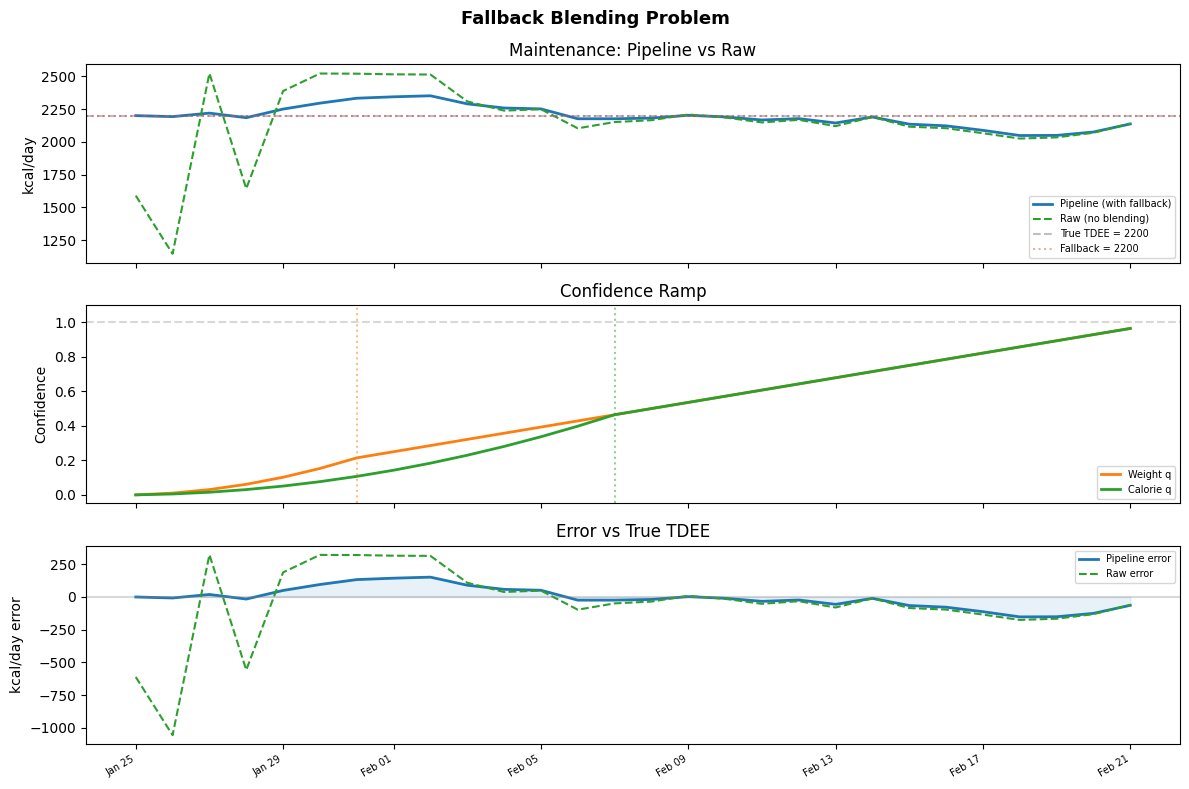


 Day   W_q   C_q  Pipeline       Raw   Error  Valid
--------------------------------------------------
   1  0.00  0.00      2200      1589      +0      ✗
   4  0.06  0.03      2184      1643     -16      ✗
   7  0.21  0.11      2333      2520    +133      ✗
  10  0.32  0.23      2290      2309     +90      ✗
  14  0.46  0.46      2176      2151     -24      ✗
  21  0.71  0.71      2189      2190     -11      ✓
  28  0.96  0.96      2136      2139     -64      ✓


In [13]:
import numpy as np
import matplotlib.dates as mdates

fb = Scenario(
    name="Fallback Demo",
    true_tdee=2200,
    intake=1600,
    weight_start=75.0,
    weight_slope=-0.6,
    days=28,
    body_fat=0.22,
    noise_weight=0.3,
    noise_calories=80,
)

weights, calories, body_fat_data = generate(fb, REF)
dates, results = rolling_pipeline(weights, calories, body_fat_data, REF, fb.days)

# Also compute "raw" maintenance (confidence forced to 1.0)
raw_maint = []
for i, ref in enumerate(dates):
    w_sub = {d: v for d, v in weights.items() if d <= ref}
    c_sub = {d: v for d, v in calories.items() if d <= ref}
    bf_sub = {d: v for d, v in body_fat_data.items() if d <= ref}

    slope_day = wls_slope(w_sub, ref_date=ref)
    slope_week = (slope_day or 0.0) * 7.0
    clamped = max(-MAX_WEIGHT_LOSS_PER_WEEK, min(MAX_WEIGHT_GAIN_PER_WEEK, slope_week))
    smoothed = ewma(c_sub, ref_date=ref) or 0.0
    rho = forbes_rho(fb.body_fat, fb.weight_start)
    raw_m = smoothed - (clamped * rho / 7.0) if smoothed > 0 else 0.0
    raw_maint.append(raw_m)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
fig.suptitle("Fallback Blending Problem", fontsize=13, fontweight="bold")

# Panel 1: Maintenance comparison
ax1.plot(
    dates,
    [r.maintenance for r in results],
    "C0-",
    lw=2,
    label="Pipeline (with fallback)",
)
ax1.plot(dates, raw_maint, "C2--", lw=1.5, label="Raw (no blending)")
ax1.axhline(
    fb.true_tdee, color="gray", ls="--", alpha=0.5, label=f"True TDEE = {fb.true_tdee}"
)
ax1.axhline(
    BASELINE_MAINTENANCE,
    color="C3",
    ls=":",
    alpha=0.4,
    label=f"Fallback = {BASELINE_MAINTENANCE:.0f}",
)
ax1.set(ylabel="kcal/day", title="Maintenance: Pipeline vs Raw")
ax1.legend(fontsize=7)

# Panel 2: Confidence ramp
ax2.plot(dates, [r.weight_confidence for r in results], "C1-", lw=2, label="Weight q")
ax2.plot(dates, [r.calorie_confidence for r in results], "C2-", lw=2, label="Calorie q")
ax2.axhline(1.0, color="gray", ls="--", alpha=0.3)
ax2.axvline(
    dates[min(MIN_WEIGHT_DATA_POINTS - 1, len(dates) - 1)],
    color="C1",
    ls=":",
    alpha=0.5,
)
ax2.axvline(
    dates[min(MIN_CALORIE_DATA_POINTS - 1, len(dates) - 1)],
    color="C2",
    ls=":",
    alpha=0.5,
)
ax2.set(ylabel="Confidence", title="Confidence Ramp", ylim=(-0.05, 1.1))
ax2.legend(fontsize=7)

# Panel 3: Error (how far off from true TDEE)
pipeline_err = [r.maintenance - fb.true_tdee for r in results]
raw_err = [rm - fb.true_tdee for rm in raw_maint]
ax3.plot(dates, pipeline_err, "C0-", lw=2, label="Pipeline error")
ax3.plot(dates, raw_err, "C2--", lw=1.5, label="Raw error")
ax3.axhline(0, color="gray", ls="-", alpha=0.3)
ax3.fill_between(dates, pipeline_err, 0, alpha=0.1, color="C0")
ax3.set(ylabel="kcal/day error", title="Error vs True TDEE")
ax3.legend(fontsize=7)

for ax in [ax1, ax2, ax3]:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=7)

plt.tight_layout()
plt.show()

# Summary table
print(
    f"\n{'Day':>4} {'W_q':>5} {'C_q':>5} {'Pipeline':>9} {'Raw':>9} {'Error':>7} {'Valid':>6}"
)
print("-" * 50)
for i in [0, 3, 6, 9, 13, 20, 27]:
    if i < len(results):
        r = results[i]
        print(
            f"{i + 1:4d} {r.weight_confidence:5.2f} {r.calorie_confidence:5.2f}"
            f" {r.maintenance:9.0f} {raw_maint[i]:9.0f}"
            f" {r.maintenance - fb.true_tdee:+7.0f} {'✓' if r.is_valid else '✗':>6}"
        )